Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score,recall_score,f1_score, roc_curve, auc)


In [2]:
plt.rcParams['figure.figsize'] = (7, 5)

Create a small synthetic dataset

In [3]:
data = {
    'Weather': ['Sunny', 'Rainy', 'Sunny', 'Sunny', 'Rainy', 'Rainy', 'Sunny', 'Rainy'],
    'Windy':   [0,        1,       0,        1,        0,        1,        0,       1],
    'Play':    [1,        0,       1,        1,        0,        0,        1,       0]
}
df_synthetic = pd.DataFrame(data)
df_synthetic

,Weather,Windy,Play
0,Sunny,0,1
1,Rainy,1,0
2,Sunny,0,1
3,Sunny,1,1
4,Rainy,0,0
5,Rainy,1,0
6,Sunny,0,1
7,Rainy,1,0


In [4]:
# Encoding categorical features
df_synthetic['Weather_Number'] = df_synthetic['Weather'].map({'Sunny': 1, 'Rainy':0})

In [5]:
# Prepare X and Y
X_syn = df_synthetic[['Weather_Number', 'Windy']]
y_syn = df_synthetic['Play']

print(X_syn)
print(y_syn)

   Weather_Number  Windy
0               1      0
1               0      1
2               1      0
3               1      1
4               0      0
5               0      1
6               1      0
7               0      1
0    1
1    0
2    1
3    1
4    0
5    0
6    1
7    0
Name: Play, dtype: int64


In [6]:
# Train a simple Decision Tree
tree_syn = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_syn.fit(X_syn, y_syn)
tree_syn

DecisionTreeClassifier(max_depth=3, random_state=42)

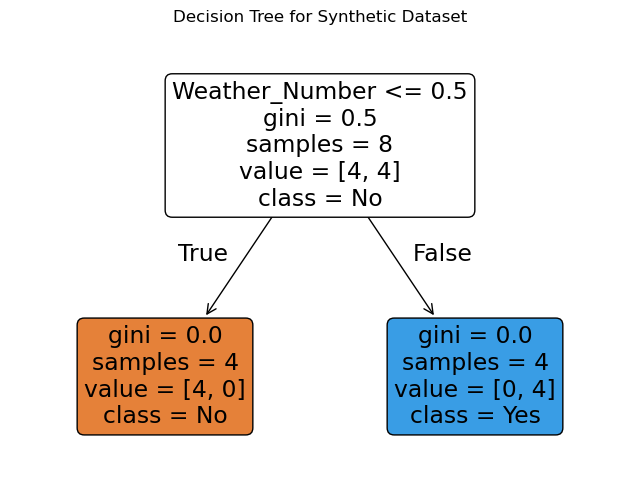

In [7]:
# Visualize the tree
plt.figure(figsize=(8,6))
plot_tree(
    tree_syn,
    feature_names=['Weather_Number','Windy'],
    class_names=['No', 'Yes'],
    filled=True,
    rounded=True
    )
plt.title("Decision Tree for Synthetic Dataset")
plt.show()

Prediction Example

In [8]:
# Sunny(1) and not Windy(0)
exp1 =  pd.DataFrame([[1,0]], columns=['Weather_Number','Windy'])
pred1 = tree_syn.predict(exp1)[0]
print('Sunny and not Windy: Play Prediction', pred1)

Sunny and not Windy: Play Prediction 1


In [9]:
# Rainy(0) and Windy(1)
exp2 =  pd.DataFrame([[0,1]], columns=['Weather_Number','Windy'])
pred2 = tree_syn.predict(exp2)[0]
print('Rainy and Windy: Play Prediction', pred2)

Rainy and Windy: Play Prediction 0


### Overfitting and Pruning

In [10]:
from sklearn.datasets import make_classification

X_big, y_big = make_classification(
    n_samples=400, # Total Data points
    n_features=5, # Total Features
    n_informative=3, # Informative Features
    n_redundant=0, # No Strongly Correlated Features
    n_classes=2, # Target Variable/ Feature Class number
    random_state=42 # Every time we will get the similar random dataset
)

X_train_big, X_test_big, y_train_big, y_test_big = train_test_split(
    X_big, y_big, test_size=0.3, random_state=42
)

X_train_big.shape, X_test_big.shape

((280, 5), (120, 5))

Train a deep tree vs pruned tree

In [11]:
deep_tree = DecisionTreeClassifier(random_state=42)
deep_tree.fit(X_train_big, y_train_big)

pruned_tree = DecisionTreeClassifier(max_depth=3, random_state=41)
pruned_tree.fit(X_train_big, y_train_big)

y_train_pred_deep = deep_tree.predict(X_train_big)
y_test_pred_deep = deep_tree.predict(X_test_big)

y_train_pred_pruned = pruned_tree.predict(X_train_big)
y_test_pred_pruned = pruned_tree.predict(X_test_big)

print('Deep tree - Train accuracy: ', round(accuracy_score(y_train_big, y_train_pred_deep),3))
print('Deep tree - Test accuracy: ', round(accuracy_score(y_test_big, y_test_pred_deep),3))
print()
print('Pruned tree - Train accuracy: ', round(accuracy_score(y_train_big, y_train_pred_pruned),3))
print('Pruned tree - Test accuracy: ', round(accuracy_score(y_test_big, y_test_pred_pruned),3))


Deep tree - Train accuracy:  1.0
Deep tree - Test accuracy:  0.883

Pruned tree - Train accuracy:  0.904
Pruned tree - Test accuracy:  0.892


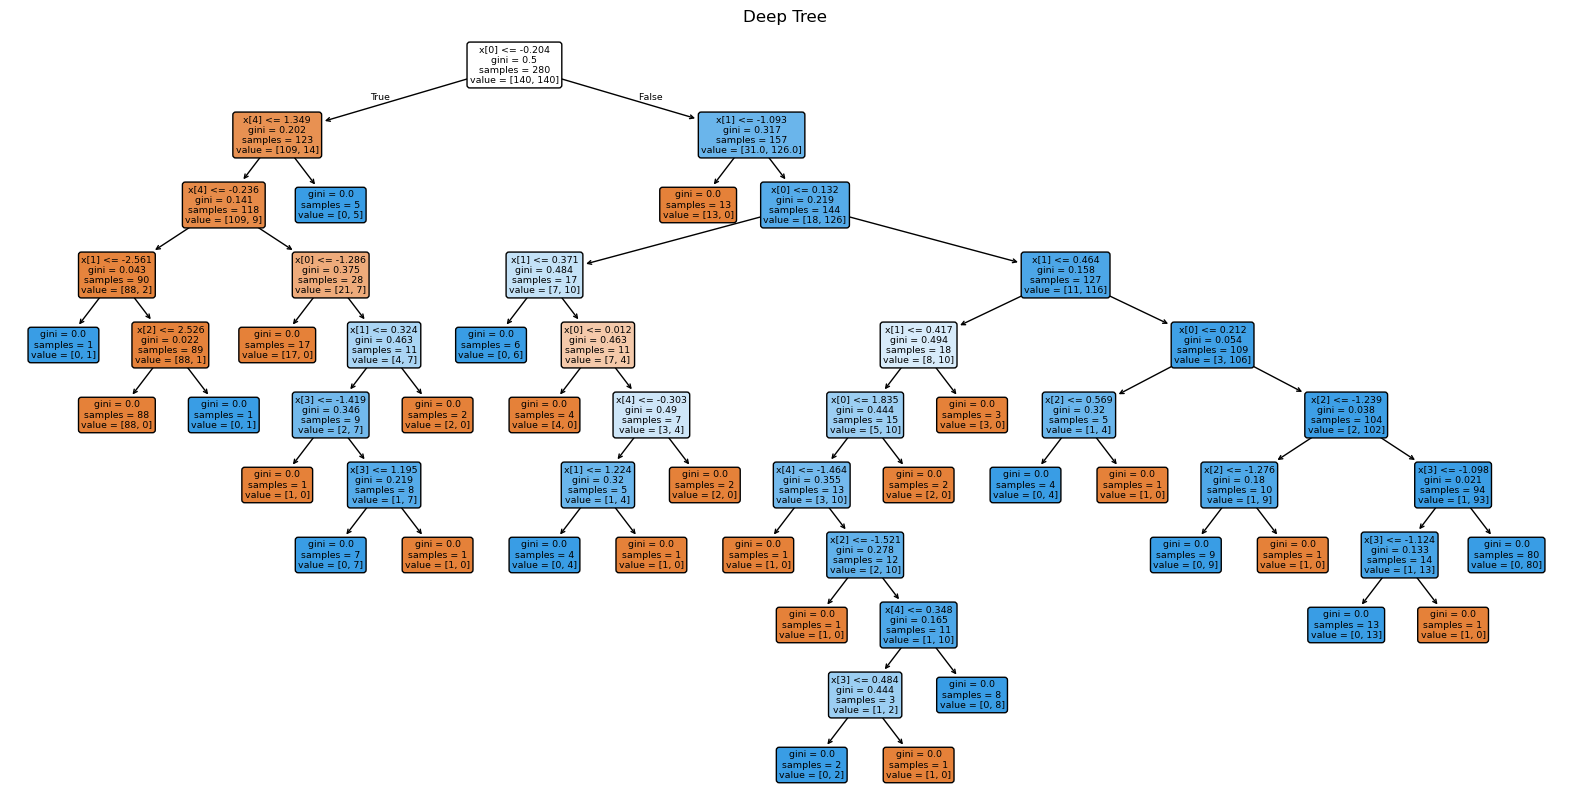

In [12]:
plt.figure(figsize=(20,10))
plot_tree(
    deep_tree,
    filled=True,
    rounded=True,
)

plt.title('Deep Tree')
plt.show()

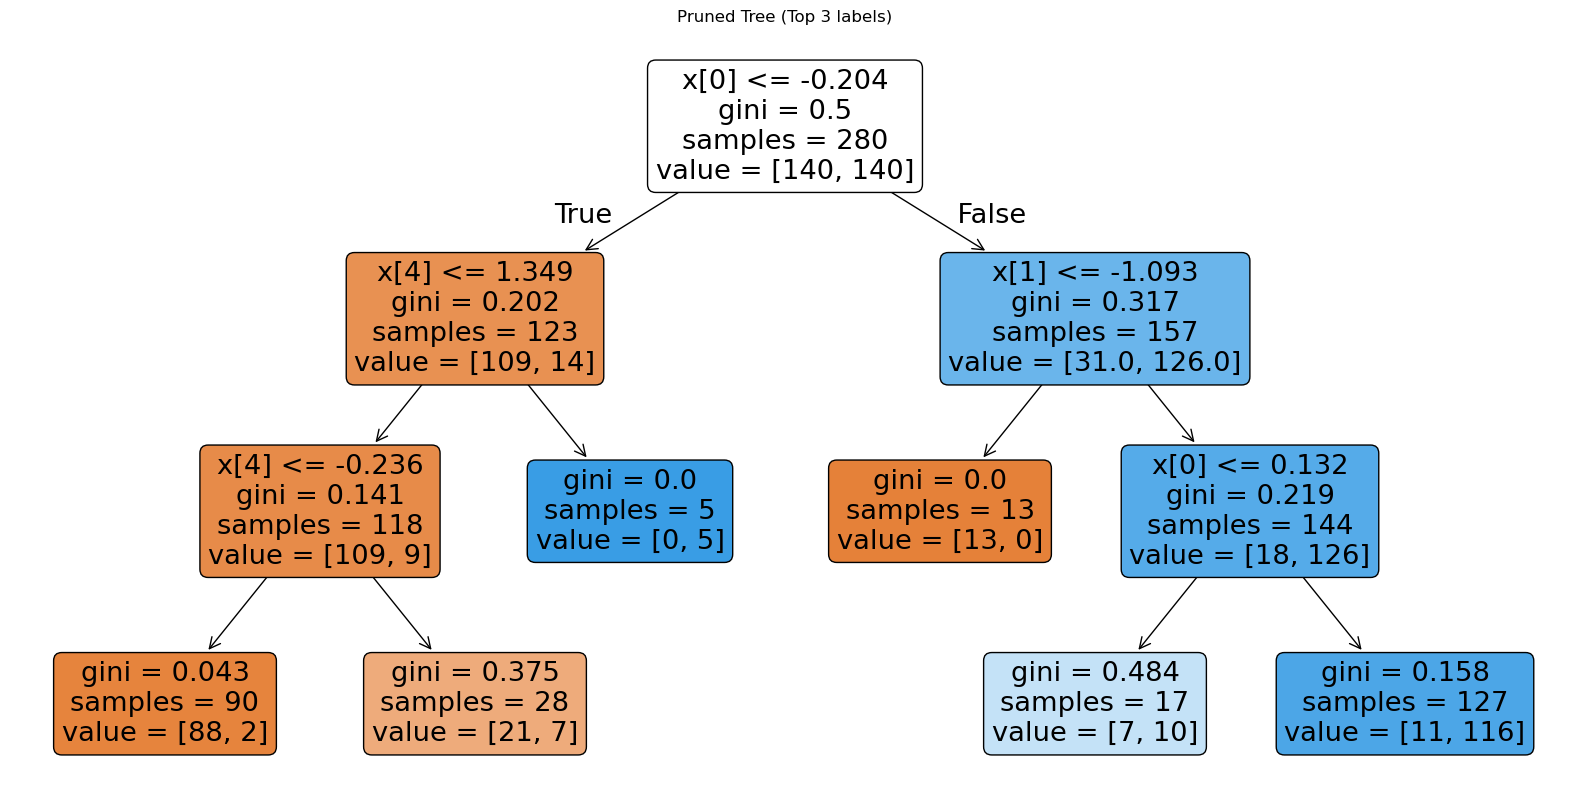

In [13]:
plt.figure(figsize=(20,10))
plot_tree(
    pruned_tree,
    filled=True,
    rounded=True,
    max_depth=3
)

plt.title('Pruned Tree (Top 3 labels)')
plt.show()

### Evaluating a decision tree

In [14]:
np.random.seed(42)
n_samples = 300

age = np.random.randint(30, 80, size = n_samples)
chol = np.random.randint(150, 300, size=n_samples)
thalach = np.random.randint(90, 200, size= n_samples)

risk_score = 0.03 * (age-40) + 0.02 * (chol - 200) - 0.02 * (thalach - 140)
prob = 1 / (1 + np.exp(-0.05 * risk_score))

target = (prob > np.median(prob)).astype(int)

df_heart = pd.DataFrame({
    'age' : age,
    'cholesterol': chol,
    'thalach': thalach,
    'target': target
})

df_heart.head(10)

,age,cholesterol,thalach,target
0,68,253,128,1
1,58,233,90,1
2,44,261,92,1
3,72,248,166,1
4,37,242,181,0
5,50,295,151,1
6,68,277,152,1
7,48,259,114,1
8,52,231,145,0
9,40,203,122,0


Train test split and model training

In [15]:
X_heart = df_heart[['age','cholesterol', 'thalach']]
y_heart = df_heart['target']
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42
)

tree_heart = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_heart.fit(X_train_h, y_train_h)

tree_heart

DecisionTreeClassifier(max_depth=4, random_state=42)

In [16]:
# Confution Matrinx
y_pred_h = tree_heart.predict(X_test_h)
cm = confusion_matrix(y_test_h, y_pred_h)

print(cm)

[[23  3]
 [ 6 28]]


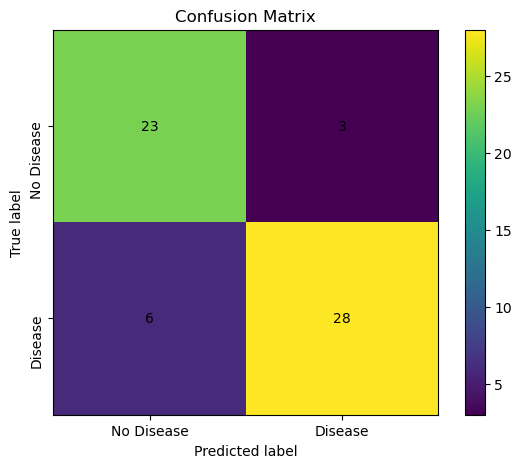

In [17]:
# Plot confusion matrix
fig, ax = plt.subplots()
im = ax.imshow(cm, interpolation='nearest')
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")

ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(['No Disease', 'Disease'])
ax.set_yticklabels(['No Disease', 'Disease'], rotation=90)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j,i, cm[i,j], ha='center', va='center')
        
plt.colorbar(im)
plt.show()

In [18]:
# Accuracy
accuracy = accuracy_score(y_test_h, y_pred_h)

print('Accuracy:', round(accuracy,3))

Accuracy: 0.85


In [19]:
# Precision
prec = precision_score(y_test_h, y_pred_h)
print('Precision:', round(prec,3))


Precision: 0.903


In [20]:
# Recall 
rec = recall_score(y_test_h, y_pred_h)
print('Recall:', round(rec,3))

Recall: 0.824


In [21]:
# F1 Score
f1 = f1_score(y_test_h, y_pred_h)
print('F1 Score:', round(f1,3)) 

F1 Score: 0.862


##### ROC Curve and AUC

In [23]:
#Predicted Probabilities
y_prob_h = tree_heart.predict_proba(X_test_h)[:,1]
y_prob_h[:10]

array([0.875     , 0.        , 0.04761905, 0.        , 0.875     ,
       1.        , 1.        , 1.        , 1.        , 0.        ])

In [24]:
# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_h, y_prob_h)
roc_auc = auc(fpr, tpr)
print('AUC: ', round(roc_auc, 3))

AUC:  0.925


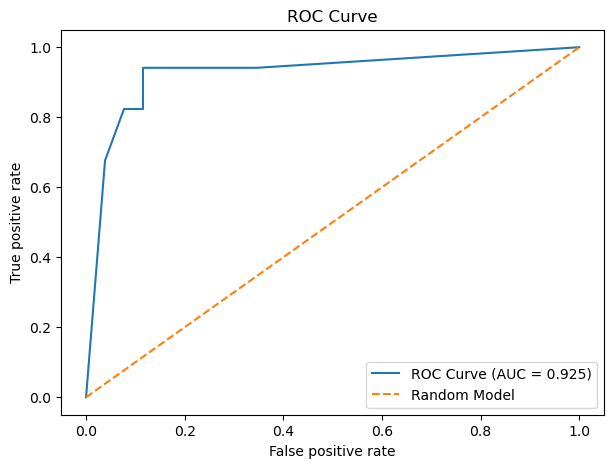

In [25]:
# Plot
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1], linestyle='--', label = 'Random Model')
plt.title('ROC Curve')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend()
plt.show()

1. A Curve closer to the Top left corner is better
2. AUC near 1.0 means strong separation between classes
3. AUC near 0.5 means the model is no better than random 